In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
from google.colab import files
uploaded = files.upload()


Saving matches_r.csv to matches_r.csv


In [3]:
df = pd.read_csv('matches_r.csv')

print("Total Rows and Columns:", df.shape)
print("\nColumn Names:\n", df.columns.tolist())
print("\nFirst 5 Rows:")
df.head()

Total Rows and Columns: (193530, 13)

Column Names:
 ['tournament_id', 'match_id', 'date', 'stage', 'best_of', 'player1_name', 'player1_url', 'player2_name', 'player2_url', 'score1', 'score2', 'frames_scores', 'is_walkover']

First 5 Rows:


,tournament_id,match_id,date,stage,best_of,player1_name,player1_url,player2_name,player2_url,score1,score2,frames_scores,is_walkover
0,753,82716,NaN,Final,31,Terry Griffiths,https://cuetracker.net/players/terry-griffiths,Alex Higgins,https://cuetracker.net/players/alex-higgins,16,15,20-58; 31-90; 56-52; 26-87(67); 0-114(67); 73(...,False
1,753,82718,NaN,Semi-final,17,Terry Griffiths,https://cuetracker.net/players/terry-griffiths,Tony Meo,https://cuetracker.net/players/tony-meo,9,7,71-8; 50-71(55); 31-62; 69-30; 73-61; 34-77(52...,False
2,753,82717,NaN,Semi-final,17,Alex Higgins,https://cuetracker.net/players/alex-higgins,Ray Reardon,https://cuetracker.net/players/ray-reardon,9,6,28-71; 67(50)-29; 74(74)-0; 53-79; 60-54; 112(...,False
3,753,82721,NaN,Quarter-final,17,Terry Griffiths,https://cuetracker.net/players/terry-griffiths,Steve Davis,https://cuetracker.net/players/steve-davis,9,6,"1-103; 117(60,57)-6; 5-105(60); 57-60; 79-0; 2...",False
4,753,82719,NaN,Quarter-final,17,Alex Higgins,https://cuetracker.net/players/alex-higgins,John Spencer,https://cuetracker.net/players/john-spencer,9,5,69(54)-31; 103-21; 72-48; 33-82; 40-56; 71-51;...,False


In [4]:
print("Data Types:")
print(df.dtypes)

print("\nMissing Values:")
print(df.isnull().sum())

print("\nBasic Statistical Summary:")
df.describe()

Data Types:
tournament_id     int64
match_id          int64
date             object
stage            object
best_of           int64
player1_name     object
player1_url      object
player2_name     object
player2_url      object
score1            int64
score2            int64
frames_scores    object
is_walkover        bool
dtype: object

Missing Values:
tournament_id         0
match_id              0
date             138711
stage                 0
best_of               0
player1_name          0
player1_url           0
player2_name          0
player2_url           0
score1                0
score2                0
frames_scores    123278
is_walkover           0
dtype: int64

Basic Statistical Summary:


,tournament_id,match_id,best_of,score1,score2
count,193530.000000,193530.000000,193530.000000,193530.000000,193530.000000
mean,1309.002103,104282.457076,7.615512,4.212629,1.632403
std,990.437857,60048.907657,3.198767,1.720625,1.636641
min,1.000000,1.000000,-1.000000,0.000000,0.000000
25%,440.000000,52095.250000,5.000000,3.000000,0.000000
50%,1116.000000,105023.500000,7.000000,4.000000,1.000000
75%,2261.000000,155859.750000,9.000000,5.000000,3.000000
max,3363.000000,208001.000000,35.000000,18.000000,17.000000


/tmp/ipykernel_1404/3379823913.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_players.values, y=top_players.index, palette='viridis')


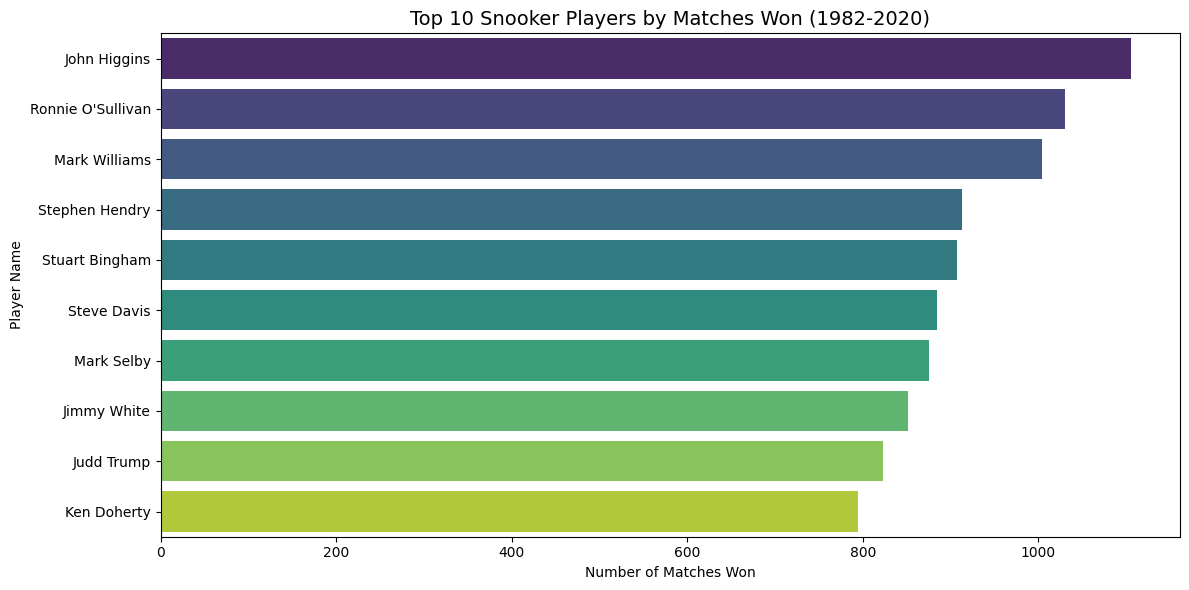

In [5]:
df['winner_name'] = df.apply(lambda row: row['player1_name'] if row['score1'] > row['score2'] else row['player2_name'], axis=1)

top_players = df['winner_name'].value_counts().head(10)

plt.figure(figsize=(12, 6))
sns.barplot(x=top_players.values, y=top_players.index, palette='viridis')
plt.title('Top 10 Snooker Players by Matches Won (1982-2020)', fontsize=14)
plt.xlabel('Number of Matches Won')
plt.ylabel('Player Name')
plt.tight_layout()
plt.show()

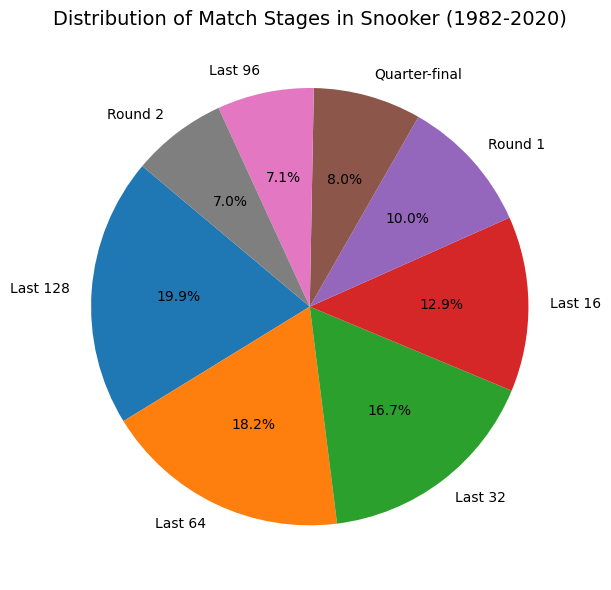

In [6]:
stage_counts = df['stage'].value_counts().head(8)

plt.figure(figsize=(10, 6))
plt.pie(stage_counts.values, labels=stage_counts.index, autopct='%1.1f%%', startangle=140)
plt.title('Distribution of Match Stages in Snooker (1982-2020)', fontsize=14)
plt.tight_layout()
plt.show()

In [8]:
print("=" * 50)
print("KEY INSIGHTS FROM SNOOKER DATA (1982-2020)")
print("=" * 50)

print(f"\n1. Total Matches Analyzed: {len(df):,}")
print(f"\n2. Top Player: {df['winner_name'].value_counts().index[0]} with {df['winner_name'].value_counts().values[0]:,} wins")
print(f"\n3. Most Common Stage: {df['stage'].value_counts().index[0]} ({df['stage'].value_counts().values[0]:,} matches)")
print(f"\n4. Average Score (Winner): {df['score1'].mean():.2f} frames")
print(f"\n5. Walkover Matches: {df['is_walkover'].sum():,} out of {len(df):,} total matches")

KEY INSIGHTS FROM SNOOKER DATA (1982-2020)

1. Total Matches Analyzed: 193,530

2. Top Player: John Higgins with 1,106 wins

3. Most Common Stage: Last 128 (19,522 matches)

4. Average Score (Winner): 4.21 frames

5. Walkover Matches: 4,596 out of 193,530 total matches
